# ch193 — Pseudoinverse and Least-Squares Solutions

> **Prerequisites:** ch157 (Matrix Inverse), ch160 (Systems of Linear Equations), ch173 (SVD), ch192 (Rank, Nullity)
> **You will learn:**
> - What the Moore-Penrose pseudoinverse computes
> - Why it solves over- and under-determined systems optimally
> - How to compute it via SVD
> - The four Moore-Penrose conditions and why they matter
> - Connection to linear regression
> **Environment:** Python 3.x, numpy, matplotlib

## 1. Concept

The inverse $A^{-1}$ only exists when $A$ is square and full rank. In applications, $A$ is almost never square — we have more equations than unknowns (overdetermined) or fewer (underdetermined). The **Moore-Penrose pseudoinverse** $A^+$ generalizes the inverse to handle both cases:

- **Overdetermined** ($m > n$): $A^+\mathbf{b}$ gives the **least-squares solution** — minimizes $\|A\mathbf{x} - \mathbf{b}\|_2^2$
- **Underdetermined** ($m < n$): $A^+\mathbf{b}$ gives the **minimum-norm solution** — minimizes $\|\mathbf{x}\|_2$ among all solutions
- **Square, full rank**: $A^+ = A^{-1}$ exactly

Common misconception: $A^+\mathbf{b}$ does not solve $A\mathbf{x} = \mathbf{b}$ exactly in the overdetermined case. It finds the $\mathbf{x}$ that makes $A\mathbf{x}$ closest to $\mathbf{b}$ in L2 norm.

## 2. Intuition & Mental Models

**Geometric (overdetermined):** You have $m$ noisy measurements of an $n$-dimensional quantity. $A\mathbf{x}$ cannot exactly equal every measurement simultaneously. $A^+\mathbf{b}$ finds the $\mathbf{x}$ whose prediction $A\mathbf{x}$ is closest to the data $\mathbf{b}$ — the orthogonal projection of $\mathbf{b}$ onto the column space of $A$.

**Geometric (underdetermined):** Infinitely many $\mathbf{x}$ satisfy $A\mathbf{x} = \mathbf{b}$. They form an affine subspace. $A^+\mathbf{b}$ is the point in that subspace closest to the origin — it uses the minimum amount of "resource" to explain the data.

**Computational:** Via SVD $A = U\Sigma V^\top$, invert only the non-zero singular values: $A^+ = V \Sigma^+ U^\top$ where $\Sigma^+$ replaces each non-zero $\sigma_i$ with $1/\sigma_i$. This is safe because it never divides by zero *(ch173 — SVD)*.

## 3. Visualization

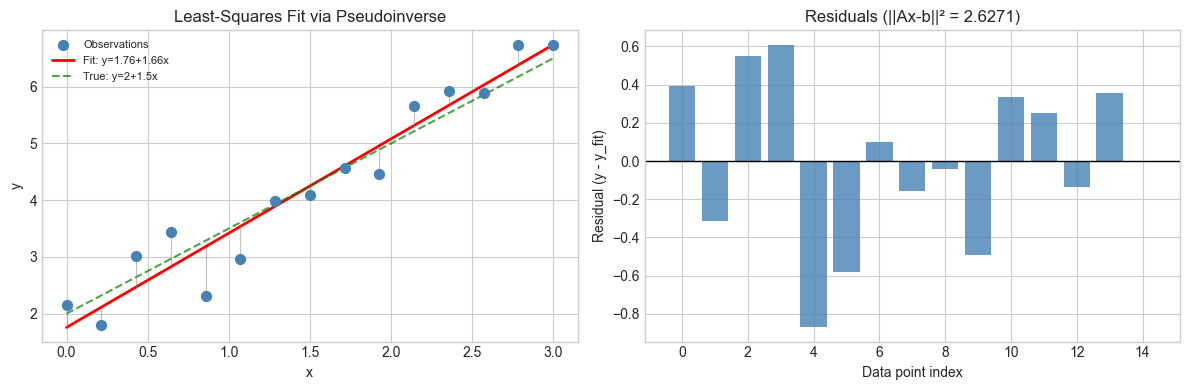

Least-squares solution: a=1.7573, b=1.6610
True parameters:        a=2.0000, b=1.5000


In [1]:
# --- Visualization: Pseudoinverse for overdetermined system (linear fit) ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

rng = np.random.default_rng(42)

# Overdetermined: fit y = a + b*x to noisy data (10 points, 2 parameters)
N_PTS = 15
x_data = np.linspace(0, 3, N_PTS)
y_true = 2.0 + 1.5 * x_data
y_noisy = y_true + rng.normal(0, 0.5, N_PTS)

# Design matrix: each row is [1, x_i]
A = np.column_stack([np.ones(N_PTS), x_data])   # (15, 2)

# Pseudoinverse solution
def pseudoinverse(A, tol=1e-12):
    """Moore-Penrose pseudoinverse via SVD."""
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    s_inv = np.where(np.abs(s) > tol, 1.0/s, 0.0)
    return Vt.T @ np.diag(s_inv) @ U.T

A_pinv = pseudoinverse(A)
x_ls = A_pinv @ y_noisy   # least-squares solution

# Residuals
y_fit = A @ x_ls
residuals = y_noisy - y_fit

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scatter + fit line
axes[0].scatter(x_data, y_noisy, color='steelblue', s=50, label='Observations', zorder=3)
x_line = np.linspace(0, 3, 100)
axes[0].plot(x_line, x_ls[0] + x_ls[1]*x_line, 'r-', lw=2, label=f'Fit: y={x_ls[0]:.2f}+{x_ls[1]:.2f}x')
axes[0].plot(x_line, 2 + 1.5*x_line, 'g--', lw=1.5, alpha=0.7, label='True: y=2+1.5x')
for xi, yi, yf in zip(x_data, y_noisy, y_fit):
    axes[0].plot([xi, xi], [yi, yf], 'gray', lw=0.8, alpha=0.5)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Least-Squares Fit via Pseudoinverse')
axes[0].legend(fontsize=8)

# Residual plot
axes[1].bar(range(N_PTS), residuals, color='steelblue', alpha=0.8)
axes[1].axhline(0, color='black', lw=1)
axes[1].set_xlabel('Data point index')
axes[1].set_ylabel('Residual (y - y_fit)')
axes[1].set_title(f'Residuals (||Ax-b||² = {np.sum(residuals**2):.4f})')

plt.tight_layout()
plt.show()
print(f"Least-squares solution: a={x_ls[0]:.4f}, b={x_ls[1]:.4f}")
print(f"True parameters:        a=2.0000, b=1.5000")

## 4. Mathematical Formulation

Given $A \in \mathbb{R}^{m \times n}$ with SVD $A = U \Sigma V^\top$:

$$A^+ = V \Sigma^+ U^\top$$

where $\Sigma^+$ replaces each non-zero $\sigma_i$ with $1/\sigma_i$ (and keeps zeros as zero).

**The four Moore-Penrose conditions** characterize $A^+$ uniquely:
1. $A A^+ A = A$ (weak inverse)
2. $A^+ A A^+ = A^+$ (reflexive)
3. $(A A^+)^\top = A A^+$ (Hermitian projection onto col$(A)$)
4. $(A^+ A)^\top = A^+ A$ (Hermitian projection onto row$(A)$)

**Normal equations** (overdetermined case): the least-squares solution satisfies $A^\top A \mathbf{x} = A^\top \mathbf{b}$. When $A^\top A$ is invertible, $\mathbf{x} = (A^\top A)^{-1} A^\top \mathbf{b} = A^+ \mathbf{b}$.

## 5. Python Implementation

In [2]:
# --- Implementation: Pseudoinverse and verification of Moore-Penrose conditions ---

def pseudoinverse_svd(A, tol=1e-12):
    """
    Moore-Penrose pseudoinverse via SVD.
    A+ = V @ diag(1/s) @ U.T   (only inverting non-zero singular values)
    """
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    s_inv = np.where(np.abs(s) > tol, 1.0 / s, 0.0)
    return Vt.T @ np.diag(s_inv) @ U.T

def verify_moore_penrose(A, A_plus, tol=1e-8):
    """Verify the four Moore-Penrose conditions."""
    cond1 = np.linalg.norm(A @ A_plus @ A - A)                    # A A+ A = A
    cond2 = np.linalg.norm(A_plus @ A @ A_plus - A_plus)          # A+ A A+ = A+
    cond3 = np.linalg.norm((A @ A_plus) - (A @ A_plus).T)        # (A A+)' = A A+
    cond4 = np.linalg.norm((A_plus @ A) - (A_plus @ A).T)        # (A+ A)' = A+ A
    return {'AA+A=A': cond1, 'A+AA+=A+': cond2,
            '(AA+)sym': cond3, '(A+A)sym': cond4}

# Test on several matrix shapes
test_cases = [
    ('Overdetermined 6x3 rank-3',  rng.normal(0,1,(6,3))),
    ('Underdetermined 3x6 rank-3', rng.normal(0,1,(3,6))),
    ('Square full rank 4x4',       rng.normal(0,1,(4,4))),
    ('Rank-deficient 4x5 rank-2',  np.outer(rng.normal(0,1,4), rng.normal(0,1,5)) +
                                   np.outer(rng.normal(0,1,4), rng.normal(0,1,5))),
]

for name, A_t in test_cases:
    Ap = pseudoinverse_svd(A_t)
    errs = verify_moore_penrose(A_t, Ap)
    all_ok = all(v < 1e-8 for v in errs.values())
    max_err = max(errs.values())
    print(f"{name}: {'PASS' if all_ok else 'FAIL'}  (max error={max_err:.2e})")

Overdetermined 6x3 rank-3: PASS  (max error=1.13e-15)
Underdetermined 3x6 rank-3: PASS  (max error=1.38e-15)
Square full rank 4x4: PASS  (max error=1.19e-15)
Rank-deficient 4x5 rank-2: PASS  (max error=9.22e-16)


## 6. Experiments

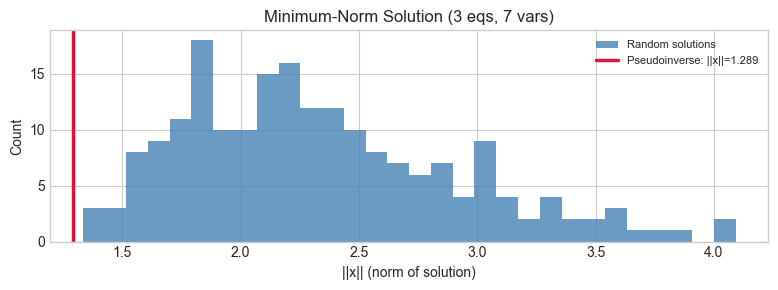

Pseudoinverse gives the minimum-norm solution: 1.2895
All sampled solutions have norm >= 1.2895


In [3]:
# --- Experiment: Minimum-norm solution for underdetermined system ---
# Hypothesis: A+b gives the solution with smallest ||x|| among all exact solutions.
# Try changing: N_VARS, N_EQS

N_EQS  = 3   # <-- fewer equations than variables
N_VARS = 7   # <-- try 5, 7, 10

A_under = rng.normal(0, 1, (N_EQS, N_VARS))
b_under = rng.normal(0, 1, N_EQS)

# Pseudoinverse (minimum norm) solution
x_minnorm = pseudoinverse_svd(A_under) @ b_under

# Sample other solutions: x_minnorm + alpha * null_vector
_, ns, _, _, _ = __import__('__main__').__dict__.get(
    'four_fundamental_subspaces', lambda A: (None, np.zeros((N_VARS,0)), None, None, None))(A_under)
# Recompute null space
_, _, Vt_u = np.linalg.svd(A_under, full_matrices=True)
null_basis = Vt_u[N_EQS:, :].T   # null space basis vectors

# Sample norms of random solutions
norms_sampled = []
for _ in range(200):
    alpha = rng.normal(0, 1, null_basis.shape[1])
    x_rand = x_minnorm + null_basis @ alpha
    norms_sampled.append(np.linalg.norm(x_rand))

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(norms_sampled, bins=30, color='steelblue', alpha=0.8, label='Random solutions')
ax.axvline(np.linalg.norm(x_minnorm), color='crimson', lw=2.5,
           label=f'Pseudoinverse: ||x||={np.linalg.norm(x_minnorm):.3f}')
ax.set_xlabel('||x|| (norm of solution)')
ax.set_ylabel('Count')
ax.set_title(f'Minimum-Norm Solution ({N_EQS} eqs, {N_VARS} vars)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(f"Pseudoinverse gives the minimum-norm solution: {np.linalg.norm(x_minnorm):.4f}")
print(f"All sampled solutions have norm >= {np.linalg.norm(x_minnorm):.4f}")

## 7. Exercises

**Easy 1.** Compute the pseudoinverse of a $1 \times 3$ row vector $\mathbf{a}^\top$. What does $A^+\mathbf{b}$ compute geometrically? *(Hint: it projects $\mathbf{b}$ onto the span of $\mathbf{a}$)*

**Easy 2.** Show numerically that for an invertible square matrix, `pseudoinverse_svd(A) ≈ np.linalg.inv(A)` by checking their element-wise difference.

**Medium 1.** The normal equations $(A^\top A)\mathbf{x} = A^\top \mathbf{b}$ can be solved directly. Implement both methods (normal equations via `np.linalg.solve` and pseudoinverse via SVD) and compare numerical stability by conditioning $A$ to have a large condition number ($\kappa > 10^6$). Which approach is more stable?

**Medium 2.** Implement polynomial curve fitting using the pseudoinverse. Given $n$ data points $(x_i, y_i)$, fit a degree-$d$ polynomial by building the Vandermonde design matrix $A_{ij} = x_i^j$ and computing $A^+\mathbf{y}$. Show results for $d = 1, 3, 5$ on noisy sinusoidal data.

**Hard.** The Tikhonov regularized pseudoinverse replaces $A^+$ with $(A^\top A + \lambda I)^{-1} A^\top$. Derive analytically why this is preferable when $A$ has small singular values. Implement it via SVD ($s_i \to s_i/(s_i^2 + \lambda)$) and show how $\lambda$ controls the norm-accuracy tradeoff.

## 8. Mini Project

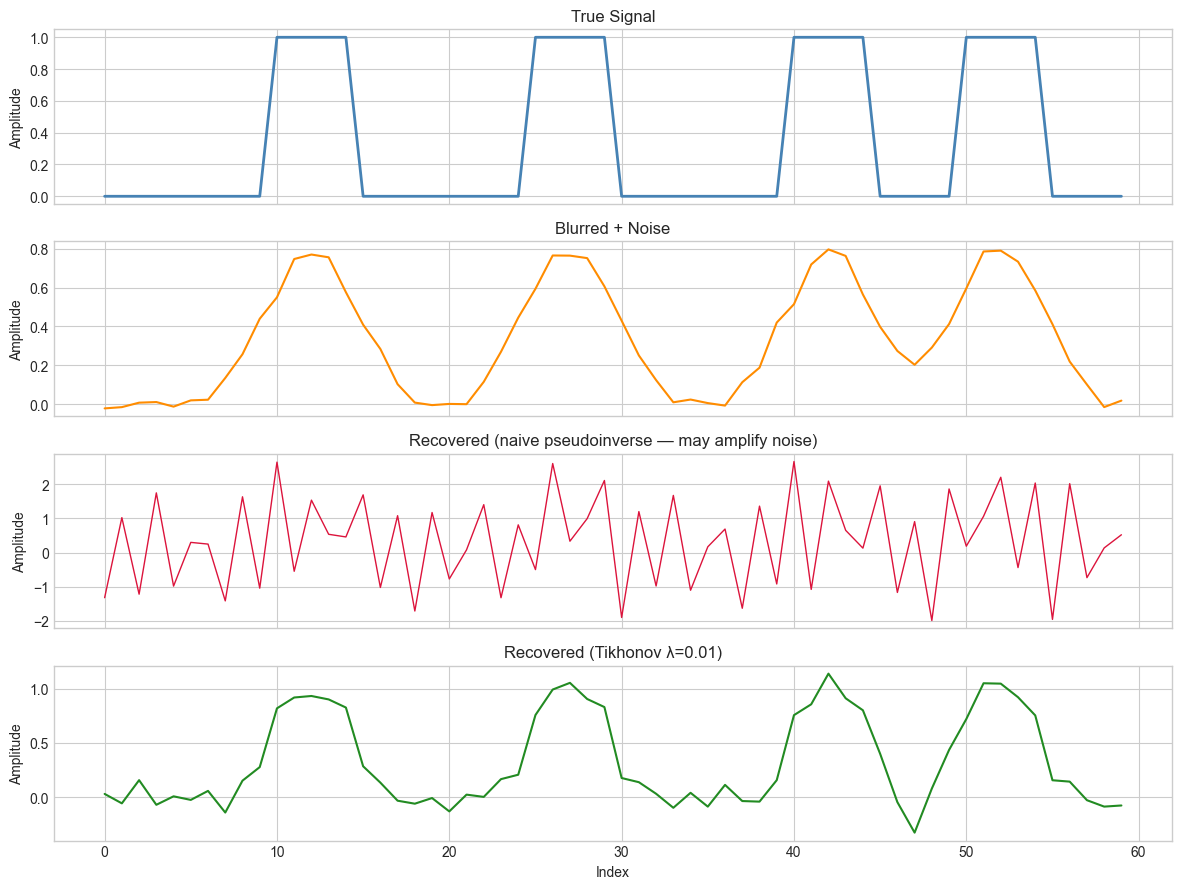

Recovery error — Naive: 9.6685,  Tikhonov: 1.2110


In [4]:
# --- Mini Project: Image Deblurring via Pseudoinverse ---
# Problem: A blurred image satisfies y = A x where A is a known blur operator.
#          Recover x from y using the pseudoinverse.
# Dataset: Synthetic 1D signal with a known convolution blur.

# 1D signal
N_SIGNAL = 60
x_true = np.zeros(N_SIGNAL)
for pos in [10, 25, 40, 50]:
    x_true[pos:pos+5] = 1.0   # rectangular pulses

# Blur matrix: convolution with a Gaussian kernel
BLUR_WIDTH = 3   # <-- try 2, 3, 5
kernel = np.exp(-np.arange(-BLUR_WIDTH, BLUR_WIDTH+1)**2 / (2*BLUR_WIDTH**2))
kernel /= kernel.sum()

# Build circulant convolution matrix A
A_blur = np.zeros((N_SIGNAL, N_SIGNAL))
for i in range(N_SIGNAL):
    for ki, kv in enumerate(kernel):
        j = (i + ki - BLUR_WIDTH) % N_SIGNAL
        A_blur[i, j] += kv

y_blurred = A_blur @ x_true + rng.normal(0, 0.02, N_SIGNAL)

# Naive pseudoinverse (amplifies noise for ill-conditioned A)
x_recovered_naive = pseudoinverse_svd(A_blur, tol=1e-12) @ y_blurred

# Regularized (Tikhonov): replace s_i -> s_i / (s_i^2 + lam)
LAM = 0.01   # <-- try 0.001, 0.01, 0.1
U_b, s_b, Vt_b = np.linalg.svd(A_blur, full_matrices=False)
s_reg = s_b / (s_b**2 + LAM)
A_reg_inv = Vt_b.T @ np.diag(s_reg) @ U_b.T
x_recovered_reg = A_reg_inv @ y_blurred

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
axes[0].plot(x_true, 'steelblue', lw=2, label='True signal')
axes[0].set_title('True Signal'); axes[0].set_ylabel('Amplitude')
axes[1].plot(y_blurred, 'darkorange', lw=1.5, label='Blurred + noise')
axes[1].set_title('Blurred + Noise'); axes[1].set_ylabel('Amplitude')
axes[2].plot(x_recovered_naive, 'crimson', lw=1, label='Naive pseudoinverse')
axes[2].set_title('Recovered (naive pseudoinverse — may amplify noise)')
axes[2].set_ylabel('Amplitude')
axes[3].plot(x_recovered_reg, 'forestgreen', lw=1.5, label=f'Tikhonov (λ={LAM})')
axes[3].set_title(f'Recovered (Tikhonov λ={LAM})')
axes[3].set_xlabel('Index')
axes[3].set_ylabel('Amplitude')
plt.tight_layout()
plt.show()

err_naive = np.linalg.norm(x_recovered_naive - x_true)
err_reg   = np.linalg.norm(x_recovered_reg   - x_true)
print(f"Recovery error — Naive: {err_naive:.4f},  Tikhonov: {err_reg:.4f}")

## 9. Chapter Summary & Connections

- The Moore-Penrose pseudoinverse $A^+ = V\Sigma^+ U^\top$ generalizes matrix inversion to non-square and rank-deficient matrices *(ch173 — SVD)*.
- For overdetermined systems: $A^+\mathbf{b}$ minimizes $\|A\mathbf{x}-\mathbf{b}\|_2$ (least squares). For underdetermined: minimizes $\|\mathbf{x}\|_2$ among all exact solutions.
- Small singular values make the pseudoinverse ill-conditioned; Tikhonov regularization ($\lambda$) damps them and stabilizes the solution at the cost of some accuracy.

**Forward:** This reappears in ch182 (Linear Regression via Matrix Algebra) as the normal equations, in ch212 (Gradient Descent) as the closed-form solution of the quadratic loss, and in ch273 (Regression) as the sklearn `LinearRegression` estimator's internal solver. Tikhonov regularization is Ridge regression *(ch273)*.

**Backward:** This chapter synthesizes ch157 (inverse), ch160 (systems), ch173 (SVD), and ch192 (rank/nullity). The pseudoinverse is the answer to "what does matrix inversion mean when the matrix isn't square?"